In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Generate points on a unit circle (only need one point for comparison)
theta = np.linspace(0, 2 * np.pi, 100)
X = np.array([np.cos(theta), np.sin(theta)]).T  # n x 2 matrix
print(len(theta), len(X))
print(theta)
print(X)

100 100
[0.         0.06346652 0.12693304 0.19039955 0.25386607 0.31733259
 0.38079911 0.44426563 0.50773215 0.57119866 0.63466518 0.6981317
 0.76159822 0.82506474 0.88853126 0.95199777 1.01546429 1.07893081
 1.14239733 1.20586385 1.26933037 1.33279688 1.3962634  1.45972992
 1.52319644 1.58666296 1.65012947 1.71359599 1.77706251 1.84052903
 1.90399555 1.96746207 2.03092858 2.0943951  2.15786162 2.22132814
 2.28479466 2.34826118 2.41172769 2.47519421 2.53866073 2.60212725
 2.66559377 2.72906028 2.7925268  2.85599332 2.91945984 2.98292636
 3.04639288 3.10985939 3.17332591 3.23679243 3.30025895 3.36372547
 3.42719199 3.4906585  3.55412502 3.61759154 3.68105806 3.74452458
 3.8079911  3.87145761 3.93492413 3.99839065 4.06185717 4.12532369
 4.1887902  4.25225672 4.31572324 4.37918976 4.44265628 4.5061228
 4.56958931 4.63305583 4.69652235 4.75998887 4.82345539 4.88692191
 4.95038842 5.01385494 5.07732146 5.14078798 5.2042545  5.26772102
 5.33118753 5.39465405 5.45812057 5.52158709 5.58505361 

In [9]:
point_idx = 0  # Select the first point for comparison
X_point = X[point_idx:point_idx+1]  # Extract one point as 1 x 2 matrix
print(X_point)

[[1. 0.]]


In [10]:
# Define covariance matrix
S = np.array([[2, 1], [1, 2]])

# Transform the single point
Y_point = X_point @ S  # Transform by covariance matrix
Y = X @ S  # Transform all points
# Calculate covariance of Y (using all points for accuracy, then apply to single point)
cov_Y = np.cov(Y.T)  # Compute covariance matrix of all transformed points
print(cov_Y)

[[2.54 2.02]
 [2.02 2.51]]


In [11]:
# Eigenvalue decomposition of cov_Y
eigenvalues, Q = np.linalg.eigh(cov_Y)
Lambda = np.diag(eigenvalues)
Lambda_inv_sqrt = np.diag(1 / np.sqrt(eigenvalues + 1e-10))  # Add small epsilon to avoid division by zero
S_inv = Q @ Lambda_inv_sqrt @ Q.T
print(S_inv)

[[ 0.93468406 -0.46909233]
 [-0.46909233  0.94165078]]


In [12]:
Z = Y @ S_inv  # Apply whitening transformation to all points
# Whitening transformation applied to the single point
Z_point = Y_point @ S_inv  # Whiten the single point
print(Z_point)

[[1.40027579 0.00346611]]


In [13]:
# Compute distances for the single point
euclidean_dist_X = np.sqrt(np.sum(X_point**2))  # Euclidean distance of original point
mahalanobis_dist_Y = np.sqrt((Y_point @ np.linalg.inv(cov_Y) @ Y_point.T)[0, 0])  # Mahalanobis distance of Y
transformed_euclidean_dist_Z = np.sqrt(np.sum(Z_point**2))  # Euclidean distance of whitened point
print(f"Euclidean distance of original point: {euclidean_dist_X}")
print(f"Mahalanobis distance of transformed point: {mahalanobis_dist_Y}")
print(f"Euclidean distance of whitened point: {transformed_euclidean_dist_Z}")

Euclidean distance of original point: 1.0
Mahalanobis distance of transformed point: 1.40028008402801
Euclidean distance of whitened point: 1.4002800839517422


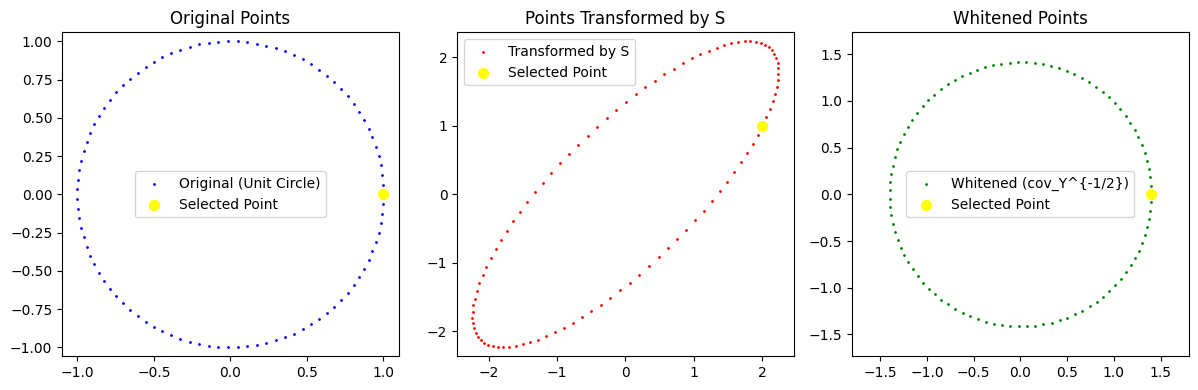

Selected Point X: [1. 0.]
Transformed Point Y: [2. 1.]
Whitened Point Z: [1.40027579 0.00346611]
Euclidean Distance of Original Point X: 1.000
Mahalanobis Distance of Transformed Point Y: 1.400
Euclidean Distance of Whitened Point Z: 1.400


In [14]:
# Plotting (optional, showing the single point context)
plt.figure(figsize=(12, 4))

plt.subplot(131)
plt.scatter(X[:, 0], X[:, 1], c='blue', label='Original (Unit Circle)', s=1)
plt.scatter(X_point[0, 0], X_point[0, 1], c='yellow', label='Selected Point', s=50)
plt.axis('equal')
plt.title('Original Points')
plt.legend()

plt.subplot(132)
plt.scatter(Y[:, 0], Y[:, 1], c='red', label='Transformed by S', s=1)
plt.scatter(Y_point[0, 0], Y_point[0, 1], c='yellow', label='Selected Point', s=50)
plt.axis('equal')
plt.title('Points Transformed by S')
plt.legend()

plt.subplot(133)
plt.scatter(Z[:, 0], Z[:, 1], c='green', label='Whitened (cov_Y^{-1/2})', s=1)
Z_all = Y @ S_inv  # Whitened all points for visualization
plt.scatter(Z_point[0, 0], Z_point[0, 1], c='yellow', label='Selected Point', s=50)
plt.axis('equal')
plt.title('Whitened Points')
plt.legend()

plt.tight_layout()
plt.show()

# Print comparison for the single point including whitened coordinates
print(f"Selected Point X: {X_point[0]}")
print(f"Transformed Point Y: {Y_point[0]}")
print(f"Whitened Point Z: {Z_point[0]}")
print(f"Euclidean Distance of Original Point X: {euclidean_dist_X:.3f}")
print(f"Mahalanobis Distance of Transformed Point Y: {mahalanobis_dist_Y:.3f}")
print(f"Euclidean Distance of Whitened Point Z: {transformed_euclidean_dist_Z:.3f}")